# 🏠 Masterclass Regresie Liniară: Matematică, Vizualizare 3D și Implementare

Acest notebook actualizat explică Regresia Liniară folosind notațiile standard din industrie (similare cursurilor Stanford/DeepLearning.ai). Include vizualizări avansate ale suprafeței de cost pentru a înțelege intuitiv cum funcționează Gradient Descent.

### 📚 Cuprins:
1.  **Fundamente Matematice**:
2.  **Generarea Datelor**.
3.  **Implementare "From Scratch"**: Algoritmul Gradient Descent optimizat.
4.  **Vizualizare 2D**: Curba de învățare (Loss over Time).
5.  **Vizualizare 3D**: Suprafața Funcției de Cost și Traseul Gradientului.
6.  **Analiza Learning Rate**: Ce se întâmplă dacă pașii sunt prea mari sau prea mici?
7.  **Scikit-Learn și Regresie Multiplă**.

## 1. Fundamente Matematice (Notația Standard)

### Ipoteza (Modelul)
Modelul liniar este definit ca:
$$ \hat{y} = w \cdot x + b $$

### Funcția de Cost (Mean Squared Error - varianta optimizată)
Pentru a simplifica derivatele, convenția standard este să împărțim eroarea pătratică la $2N$ (unde $N$ este numărul de exemple).

$$ J(w, b) = \frac{1}{2N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2 $$

### Derivatele Parțiale (Gradienții)
Vrem să aflăm direcția în care eroarea scade. Derivăm $J$ în funcție de $w$ și $b$. Deoarece am împărțit la 2 mai sus, exponentul 2 se anulează la derivare, lăsând o formulă curată:

1.  **Gradientul pentru $w$ (Panta):**
$$ \frac{\partial J}{\partial w} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i) \cdot x_i $$

2.  **Gradientul pentru $b$ (Bias):**
$$ \frac{\partial J}{\partial b} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i) $$

### Regula de Actualizare (Gradient Descent)
Mergem în direcția opusă gradientului cu un pas de mărime $\alpha$ (Learning Rate):
$$ w = w - \alpha \cdot \frac{\partial J}{\partial w} $$
$$ b = b - \alpha \cdot \frac{\partial J}{\partial b} $$

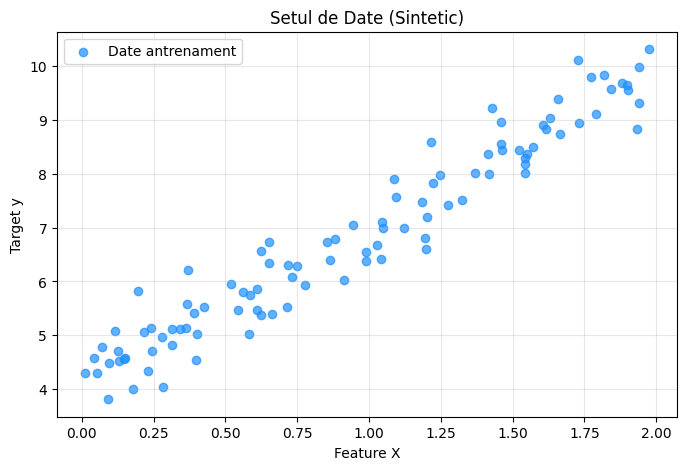

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Necesar pentru ploturi 3D

# --- 2. GENERARE DATE ---
np.random.seed(42)
N = 100

# X: Suprafața (normalizată pentru a ajuta gradient descent să conveargă mai ușor)
# Vom lucra cu valori mai mici pentru ca vizualizarea 3D să fie clară fără scalare complexă
X = 2 * np.random.rand(N, 1)
# y: Prețul = 4 + 3 * X + zgomot
true_w = 3.0
true_b = 4.0
y = true_b + true_w * X + np.random.randn(N, 1) * 0.5

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='dodgerblue', alpha=0.7, label='Date antrenament')
plt.title("Setul de Date (Sintetic)")
plt.xlabel("Feature X")
plt.ylabel("Target y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Implementare "From Scratch"

Implementăm clasa folosind exact formulele de mai sus. Vom stoca istoricul costurilor și al parametrilor ($w, b$) la fiecare pas pentru a putea construi graficele 3D ulterior.

In [ ]:
class LinearRegressionScratch:
    def __init__(self, learning_rate=0.1, epochs=100):
        self.lr = learning_rate
        self.epochs = epochs
        self.w = 0.0
        self.b = 0.0
        # Stocăm istoricul pentru vizualizare
        self.cost_history = []
        self.w_history = []
        self.b_history = []

    def fit(self, X, y):
        N = len(y)

        # Initializare parametri (random sau zero)
        self.w = 0.0
        self.b = 0.0

        for i in range(self.epochs):
            # 1. Predicția (Forward)
            y_pred = self.w * X + self.b

            # 2. Calculul Erorii (Residuals)
            error = y_pred - y

            # 3. Calculul Costului (J) - pentru monitorizare
            # Formula: 1/(2N) * sum(error^2)
            cost = (1 / (2 * N)) * np.sum(error ** 2)

            self.cost_history.append(cost)
            self.w_history.append(self.w)
            self.b_history.append(self.b)

            # 4. Calculul Gradienților (Derivate)
            # dw = 1/N * sum(error * x)
            dw = (1 / N) * np.sum(error * X)
            # db = 1/N * sum(error)
            db = (1 / N) * np.sum(error)

            # 5. Actualizarea Parametrilor
            self.w = self.w - self.lr * dw
            self.b = self.b - self.lr * db

    def predict(self, X):
        return self.w * X + self.b

# Antrenăm modelul
model = LinearRegressionScratch(learning_rate=0.1, epochs=50)
model.fit(X, y)

print(f"Parametri finali -> w: {model.w:.2f}, b: {model.b:.2f}")
print(f"Parametri reali  -> w: {true_w:.2f}, b: {true_b:.2f}")

Parametri finali -> w: 3.21, b: 3.73
Parametri reali  -> w: 3.00, b: 4.00


## 4. Vizualizare 2D: Curba de Învățare
Acest grafic este esențial în orice proiect ML. Ne arată dacă modelul "învață". Dacă linia nu scade, avem o problemă (de obicei learning rate prea mare).

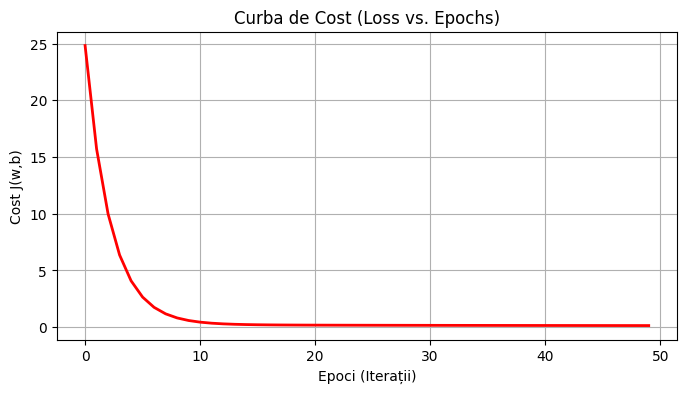

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(model.epochs), model.cost_history, color='red', linewidth=2)
plt.title("Curba de Cost (Loss vs. Epochs)")
plt.xlabel("Epoci (Iterații)")
plt.ylabel("Cost J(w,b)")
plt.grid(True)
plt.show()

## 5. Vizualizare 3D: Coborârea pe Gradient

Aici vom desena **suprafața funcției de cost**. Aceasta arată ca un bol (formă convexă).
* Axele orizontale sunt parametrii $w$ și $b$.
* Axa verticală (înălțimea) este Costul $J$.
* Linia roșie arată pașii făcuți de algoritmul nostru, plecând din $(0,0)$ și coborând spre fundul bolului (minimul global).

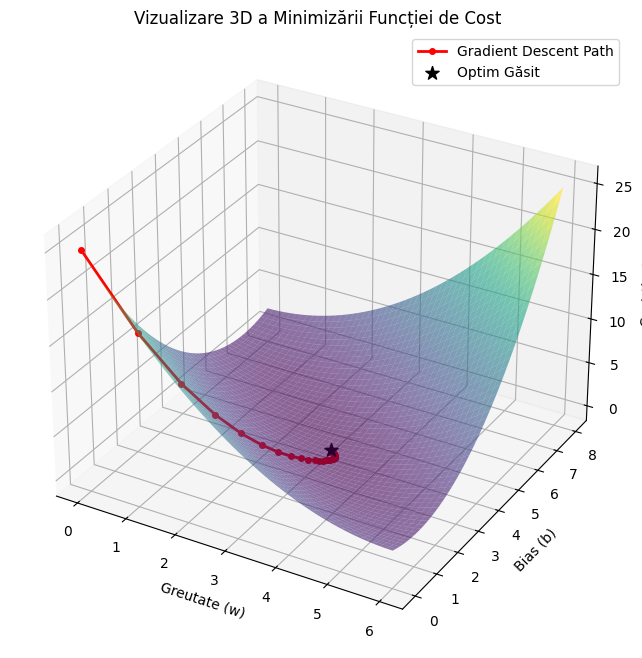

In [ ]:
# 1. Creăm un grid de valori pentru w și b
w_vals = np.linspace(0, 6, 50)
b_vals = np.linspace(0, 8, 50)
W_grid, B_grid = np.meshgrid(w_vals, b_vals)
J_grid = np.zeros_like(W_grid)

# 2. Calculăm costul pentru fiecare punct din grid
for i in range(len(w_vals)):
    for j in range(len(b_vals)):
        # Calculăm costul manual pentru fiecare pereche (w, b) posibilă
        w_temp = W_grid[i, j]
        b_temp = B_grid[i, j]
        y_pred_temp = w_temp * X + b_temp
        J_grid[i, j] = (1 / (2 * N)) * np.sum((y_pred_temp - y) ** 2)

# 3. Plotarea 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Suprafața (Bolul)
surf = ax.plot_surface(W_grid, B_grid, J_grid, cmap='viridis', alpha=0.6, edgecolor='none')

# Traseul Gradient Descent (Linia Roșie)
ax.plot(model.w_history, model.b_history, model.cost_history, color='red', marker='o', markersize=4, linewidth=2, label='Gradient Descent Path')

# Punctul Final (Optimul găsit)
ax.scatter(model.w, model.b, model.cost_history[-1], color='black', s=100, marker='*', label='Optim Găsit')

ax.set_xlabel('Greutate (w)')
ax.set_ylabel('Bias (b)')
ax.set_zlabel('Cost J(w,b)')
ax.set_title('Vizualizare 3D a Minimizării Funcției de Cost')
ax.legend()

plt.show()

## 6. Analiza Learning Rate (Contur 2D)

Ce se întâmplă dacă alegem un Learning Rate ($\\alpha$) greșit?
* **$\alpha$ mic:** Coborâm foarte lent (necesită multe epoci).
* **$\alpha$ mare:** Putem sări peste minim și să divergem (costul crește spre infinit).

Vom vizualiza acest lucru folosind **linii de contur** (o vedere de sus a bolului).

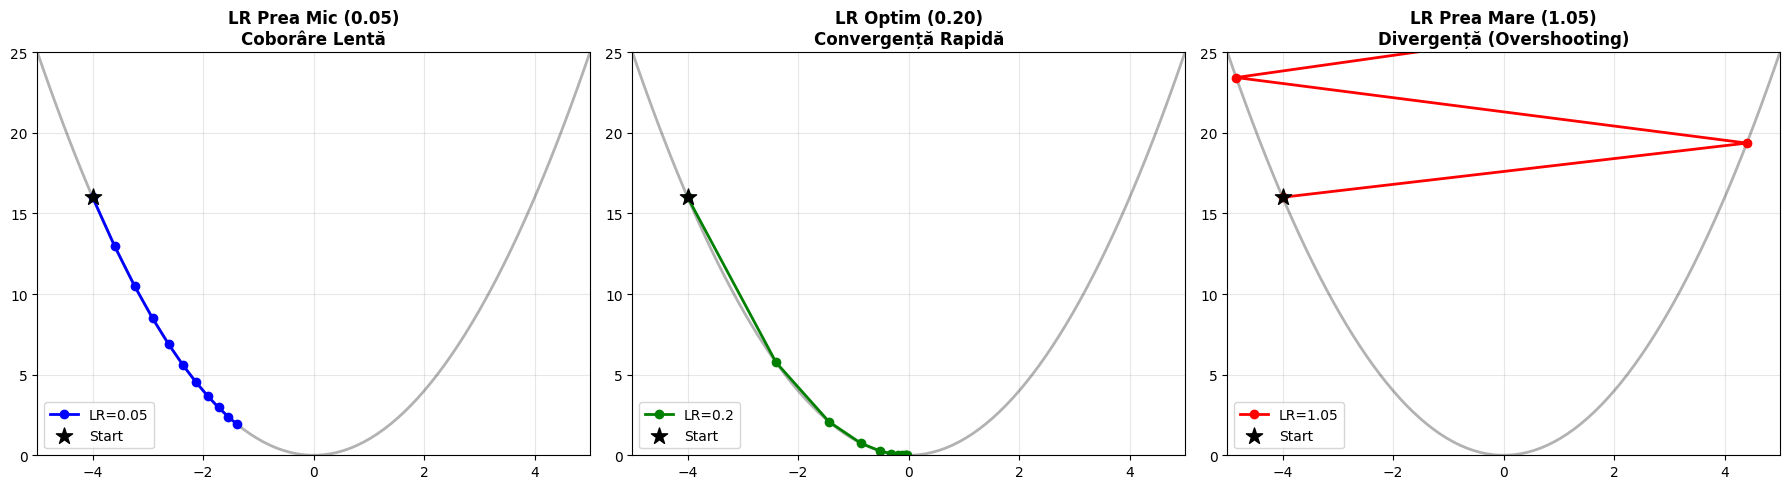

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definim funcția și derivata (Gradientul)
def cost_func(x):
    return x ** 2  # Parabolă simplă

def gradient(x):
    return 2 * x   # Derivata lui x^2 este 2x

# 2. Funcția de antrenare pentru vizualizare
def run_gradient_descent(start_x, lr, epochs=10):
    x_path = [start_x]
    y_path = [cost_func(start_x)]
    x = start_x
    for _ in range(epochs):
        grad = gradient(x)
        x = x - lr * grad
        x_path.append(x)
        y_path.append(cost_func(x))
    return x_path, y_path

# 3. Configurare Scenarii
start_x = -4.0
x_vals = np.linspace(-6, 6, 100)
y_vals = cost_func(x_vals)

# Cele 3 cazuri de studiu
scenarios = [
    {"lr": 0.05, "title": "LR Prea Mic (0.05)\nCoborâre Lentă", "color": "blue"},
    {"lr": 0.20, "title": "LR Optim (0.20)\nConvergență Rapidă", "color": "green"},
    {"lr": 1.05, "title": "LR Prea Mare (1.05)\nDivergență (Overshooting)", "color": "red"}
]

# 4. Creare Ploturi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, scen in enumerate(scenarios):
    ax = axes[i]
    lr = scen["lr"]

    # Rulăm algoritmul
    path_x, path_y = run_gradient_descent(start_x, lr, epochs=10)

    # Desenăm funcția de fundal (bolul)
    ax.plot(x_vals, y_vals, color='black', alpha=0.3, lw=2)

    # Desenăm pașii algoritmului
    ax.plot(path_x, path_y, 'o-', color=scen["color"], label=f'LR={lr}', markersize=6, lw=2)

    # Punctul de start
    ax.scatter([start_x], [cost_func(start_x)], color='black', s=150, zorder=5, marker='*', label='Start')

    # Configurări axă
    ax.set_title(scen["title"], fontsize=12, fontweight='bold')
    ax.set_ylim(0, 25) # Limităm Y pentru a vedea clar divergența în cazul 3
    ax.set_xlim(-5, 5)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

**Ce face acest cod:**

**Stânga (LR 0.05 - Prea Mic)**: Algoritmul face pași minusculi și are nevoie de foarte mult timp să ajungă la minim.

**Centru (LR 0.2 - Optim)**: Algoritmul coboară hotărât și sigur spre minim.

**Dreapta (LR 1.05 - Prea Mare)**: Algoritmul "sare" peste minim, ajunge pe peretele opus mai sus decât a plecat și continuă să urce (divergență), ieșind din grafic.

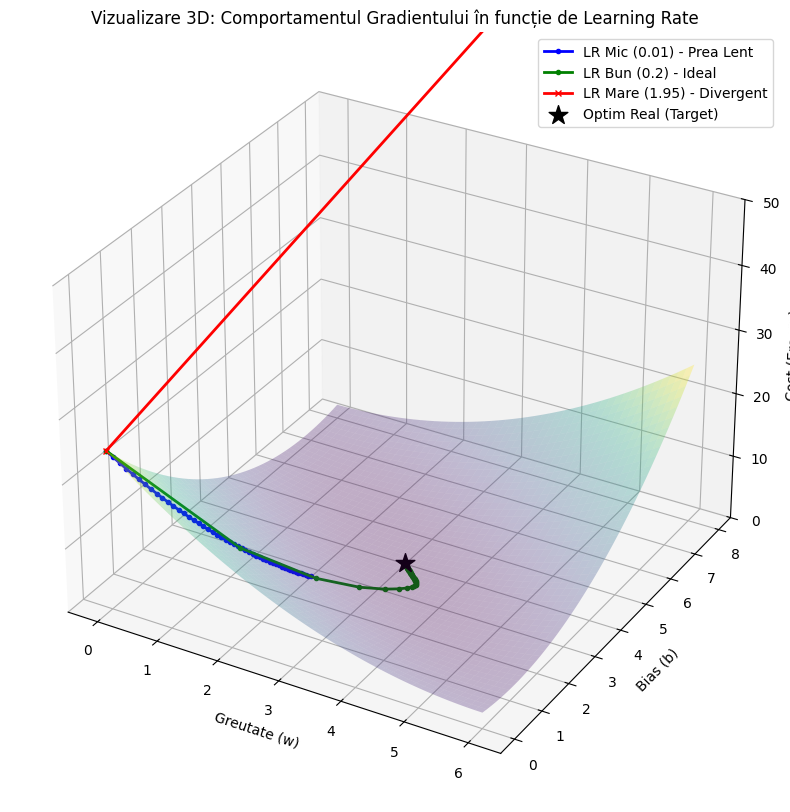

In [ ]:
# --- VIZUALIZARE 3D COMPARATIVĂ ---
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# 1. Suprafața Funcției de Cost (Bolul)
# Folosim o transparență (alpha) mai mare pentru a putea vedea liniile "prin" pereți
surf = ax.plot_surface(W_grid, B_grid, J_grid, cmap='viridis', alpha=0.3, edgecolor='none')

# 2. Plotăm cele 3 trasee
# a) LR Mic (Albastru) - Se vede cum coboară foarte lent pe perete
ax.plot(lr_small.w_history, lr_small.b_history, lr_small.cost_history,
        color='blue', marker='o', markersize=3, linewidth=2, label='LR Mic (0.01) - Prea Lent')

# b) LR Bun (Verde) - Coboară ferm și rapid spre fund
ax.plot(lr_good.w_history, lr_good.b_history, lr_good.cost_history,
        color='green', marker='o', markersize=3, linewidth=2, label='LR Bun (0.2) - Ideal')

# c) LR Mare (Roșu) - Sare haotic dintr-o parte în alta și urcă în loc să coboare
ax.plot(lr_large.w_history, lr_large.b_history, lr_large.cost_history,
        color='red', marker='x', markersize=5, linewidth=2, label='LR Mare (1.95) - Divergent')

# 3. Marcare Punct Optim
# Calculăm costul minim teoretic la parametrii reali
j_min = (1 / (2 * len(y))) * np.sum(((true_w * X + true_b) - y) ** 2)
ax.scatter(true_w, true_b, j_min, color='black', s=200, marker='*', label='Optim Real (Target)')

# --- FIX VIZUAL 3D ---
# Limităm axele pentru a "tăia" valorile extreme ale liniei roșii
# Altfel, graficul s-ar "turti" complet din cauza valorilor de cost de ordinul miilor
ax.set_xlim(-0.5, 6.5)
ax.set_ylim(-0.5, 8.5)
ax.set_zlim(0, 50) # Afișăm doar baza bolului (costuri mici/medii)

ax.set_xlabel('Greutate (w)')
ax.set_ylabel('Bias (b)')
ax.set_zlabel('Cost (Eroare)')
ax.set_title('Vizualizare 3D: Comportamentul Gradientului în funcție de Learning Rate')
ax.legend()
plt.show()

**Ce vei observa în acest grafic 3D**:

**Linia Verde**: Este ca o bilă lăsată liberă care se rostogolește natural spre fundul văii.

**Linia Albastră**: Pare "lipită" de peretele bolului și coboară milimetru cu milimetru.

**Linia Roșie**: Este cea mai interesantă în 3D. O vei vedea sărind de pe un perete pe celălalt al bolului, la înălțimi (costuri) tot mai mari, ieșind practic din grafic în sus.

## 7. Scikit-Learn și Regresie Multiplă
Pentru probleme complexe, folosim `sklearn`.

In [ ]:
from sklearn.linear_model import LinearRegression

# Regresie simplă pe datele noastre
model_sk = LinearRegression()
model_sk.fit(X, y)

print("--- Verificare Sklearn ---")
print(f"Sklearn w: {model_sk.coef_[0][0]:.4f}")
print(f"Sklearn b: {model_sk.intercept_[0]:.4f}")
print(f"Manual  w: {lr_good.w:.4f}")
print(f"Manual  b: {lr_good.b:.4f}")

--- Verificare Sklearn ---
Sklearn w: 2.8851
Sklearn b: 4.1075
Manual  w: 3.0228
Manual  b: 3.9516


## 8. Regresie Liniară Multiplă: From Scratch vs. Sklearn

Până acum am folosit o singură variabilă ($x$). În realitate, un rezultat (cum ar fi prețul unei case) depinde de mulți factori simultan (suprafață, etaj, an construcție, zonă).

### Matematică: Trecerea la Matrici (Vectorizare)
Când avem mai multe variabile, ecuația se transformă din $y = w \cdot x + b$ în:
$$y = w_1 x_1 + w_2 x_2 + ... + w_n x_n + b$$

Pentru a calcula eficient (fără bucle `for` care sunt lente), folosim **Algebra Liniară**. Putem calcula predicțiile pentru toate casele simultan folosind produsul matricial:
$$\hat{Y} = X \cdot W + b$$

Unde:
* $X$ este o matrice de formă `(Nr_Exemple, Nr_Features)`.
* $W$ este un vector de greutăți `(Nr_Features, 1)`.
* $\cdot$ este produsul matricial (dot product).

**Gradient Descent Vectorizat:**
Formulele pentru actualizarea parametrilor devin și ele operații cu matrici:
$$\nabla W = \frac{1}{N} X^T \cdot (\hat{Y} - Y)$$
$$\nabla b = \frac{1}{N} \sum (\hat{Y} - Y)$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generare Date Multiple
np.random.seed(42)
N_SAMPLES = 1000

# Features: [Suprafață, Camere, Vechime]
# Suprafața: 50-200 mp (scalăm împărțind la 100 pt stabilitate numerică)
x1 = np.random.rand(N_SAMPLES, 1) * 1.5 + 0.5
# Camere: 1-5 (scalăm împărțind la 5)
x2 = np.random.randint(1, 6, (N_SAMPLES, 1)) / 5.0
# Vechime: 0-50 ani (scalăm împărțind la 50)
x3 = np.random.rand(N_SAMPLES, 1)

# Matricea X (Feature Matrix) - le unim pe coloane
X_multi = np.hstack((x1, x2, x3))

# Target Y (Preț)
# Formula reală pe care modelul trebuie să o descopere:
# Preț = 3*Suprafață + 2*Camere - 1.5*Vechime + 0.5(Bias) + Zgomot
true_W = np.array([[3.0], [2.0], [-1.5]])
true_b = 0.5

# Generăm Y folosind produsul matricial
y_multi = X_multi.dot(true_W) + true_b + np.random.randn(N_SAMPLES, 1) * 0.1

print(f"Dimensiune X: {X_multi.shape}")
print(f"Primele 5 exemple (Suprafață, Camere, Vechime):\n{X_multi[:5]}")

Dimensiune X: (1000, 3)
Primele 5 exemple (Suprafață, Camere, Vechime):
[[1.06181018 0.8        0.4954521 ]
 [1.92607146 0.6        0.38634891]
 [1.59799091 1.         0.45012443]
 [1.39798773 0.2        0.22696469]
 [0.73402796 1.         0.88939092]]


Antrenament finalizat.


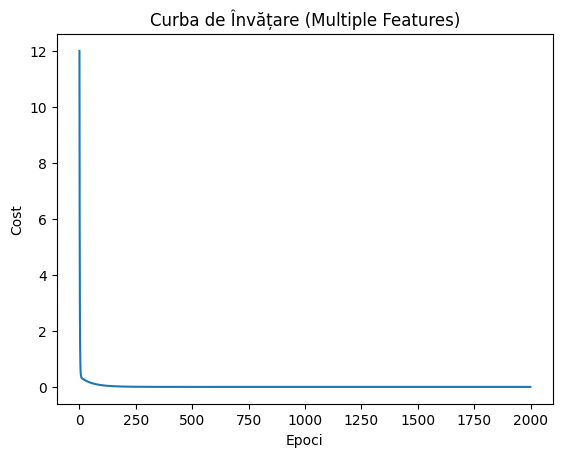

In [ ]:
class MultipleLinearRegressionScratch:
    def __init__(self, learning_rate=0.1, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.W = None
        self.b = 0
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Inițializare W cu zero-uri (dimensiune: features x 1)
        self.W = np.zeros((n_features, 1))
        self.b = 0

        for i in range(self.epochs):
            # 1. Predicție Vectorizată (X dot W)
            # Aici se întâmplă magia algebrei liniare: calculăm totul dintr-o dată
            y_pred = np.dot(X, self.W) + self.b

            # 2. Calcul Cost (Opțional, doar pt grafic)
            error = y_pred - y
            cost = (1 / (2 * n_samples)) * np.sum(error ** 2)
            self.cost_history.append(cost)

            # 3. Calcul Gradienți (Vectorizat)
            # Transpusa lui X înmulțită cu Eroarea ne dă gradientul pentru fiecare feature
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            # 4. Update Parametri
            self.W -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.W) + self.b

# Antrenăm modelul nostru vectorizat
model_multi_scratch = MultipleLinearRegressionScratch(learning_rate=0.1, epochs=2000)
model_multi_scratch.fit(X_multi, y_multi)

print("Antrenament finalizat.")
plt.plot(model_multi_scratch.cost_history)
plt.title("Curba de Învățare (Multiple Features)")
plt.xlabel("Epoci")
plt.ylabel("Cost")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

# Antrenare Sklearn (care folosește o metodă matematică exactă, nu iterativă)
model_sk_multi = LinearRegression()
model_sk_multi.fit(X_multi, y_multi)

# --- COMPARAȚIE FINALĂ ---
print(f"{'PARAMETRU':<15} | {'REAL':<10} | {'SCRATCH':<10} | {'SKLEARN':<10}")
print("-" * 55)
print(f"{'Suprafață (w1)':<15} | {true_W[0][0]:<10.2f} | {model_multi_scratch.W[0][0]:<10.2f} | {model_sk_multi.coef_[0][0]:<10.2f}")
print(f"{'Camere (w2)':<15} | {true_W[1][0]:<10.2f} | {model_multi_scratch.W[1][0]:<10.2f} | {model_sk_multi.coef_[0][1]:<10.2f}")
print(f"{'Vechime (w3)':<15} | {true_W[2][0]:<10.2f} | {model_multi_scratch.W[2][0]:<10.2f} | {model_sk_multi.coef_[0][2]:<10.2f}")
print(f"{'Bias (b)':<15} | {true_b:<10.2f} | {model_multi_scratch.b:<10.2f} | {model_sk_multi.intercept_[0]:<10.2f}")

print("\nConcluzie: Modelul nostru manual a învățat aproape aceiași parametri ca Sklearn!")

PARAMETRU       | REAL       | SCRATCH    | SKLEARN   
-------------------------------------------------------
Suprafață (w1)  | 3.00       | 3.00       | 3.00      
Camere (w2)     | 2.00       | 2.00       | 2.00      
Vechime (w3)    | -1.50      | -1.51      | -1.51     
Bias (b)        | 0.50       | 0.51       | 0.51      

Concluzie: Modelul nostru manual a învățat aproape aceiași parametri ca Sklearn!
